# 🧬 Transformer Embedding Cluster Analysis

**Purpose**: Analyze if transformer embeddings cluster meaningfully by clinical outcome

---

## 📋 What This Notebook Does

This notebook performs a comprehensive cluster analysis to answer a key question:  
**"Do transformer embeddings capture meaningful clinical patterns that separate high-risk from low-risk patients?"**

### Analysis Pipeline:
1. **Load Data**: Embeddings (256D) + Clinical Outcomes
2. **Correlation Analysis**: Which embedding dimensions predict outcomes?
3. **Dimensionality Reduction**: UMAP projection (256D → 2D for visualization)
4. **Cluster Separation**: Quantify how well embeddings separate risk groups
5. **Visualization**: Create interpretable 2D plots colored by outcome
6. **Comparison** (Optional): Test multiple embedding architectures

---

## 🎯 Key Outputs

| Output | What It Tells You |
|--------|------------------|
| **Correlation Heatmap** | Which embedding dimensions are most predictive? |
| **UMAP Scatter Plot** | Do high-risk patients cluster together visually? |
| **Density Heatmap** | Where are the "hot spots" of high risk? |
| **Cohen's D Metric** | How well do embeddings separate risk groups? |

**Interpretation Guide:**
- **Cohen's D < 0.3**: Minimal separation (embeddings don't cluster by risk)
- **Cohen's D 0.3-0.5**: Small-medium separation (some clustering)
- **Cohen's D 0.5-0.8**: Medium-large separation (clear clustering) ✅
- **Cohen's D > 0.8**: Very large separation (highly distinctive clusters)

---

## 🔧 How to Use This Notebook

### For First-Time Users:
1. **Configure Your Data Sources** (Section 0 below)
2. **Run All Cells** (Menu → Run → Run All Cells)
3. **Review Key Findings** (Jump to Section 5)
4. **Examine Visualizations** (Section 4)

### For Customization:
- **Change Embedding Source**: Update `EMBEDDING_TABLE` in configuration
- **Change Outcome**: Update `OUTCOME_TABLE` and `OUTCOME_COLUMN`
- **Adjust UMAP Parameters**: Modify `n_neighbors` and `min_dist` in Section 4
- **Compare Multiple Embeddings**: Use Section 6 as a template

---
**Owner**: Pritha Ghosh (pritha.ghosh@cvshealth.com)  
**Team**: Clinical & Social Determinants Intelligence (CSDI)  
**Created**: January 2026  
**Last Updated**: January 2026

---


---

## 0. 🔧 CONFIGURATION - **START HERE TO CUSTOMIZE**

**👉 Replace these table names with your own data sources:**


In [21]:
# ==============================================================================
# 🎯 DATA SOURCE CONFIGURATION
# ==============================================================================
# 📝 INSTRUCTIONS:
#    1. Update EMBEDDING_TABLE to your transformer embedding table
#    2. Update OUTCOME_TABLE to your outcomes/labels table  
#    3. Update OUTCOME_COLUMN to your binary outcome column name (0/1)
#    4. Update JOIN_KEYS to match how your tables join
#    5. Run all cells to generate cluster analysis
# ==============================================================================

# PRIMARY EMBEDDING SOURCE (Main Analysis - Sections 1-5)
EMBEDDING_TABLE = "edp-prod-storage.edp_ent_sdoheir_cns.a964286_te4exp_3lob_exp_round5_v2_exp1_dense_baseline_opt_config_medicare_all_sample_embedding"
EMBEDDING_NAME = "opt_config"  # Short name for display

# OUTCOME/LABEL TABLE
OUTCOME_TABLE = "edp-prod-storage.edp_ent_sdoheir_cns.a834793_Medicare_holdout_members_with_features"
OUTCOME_COLUMN = "ip6"  # Binary outcome column (0=low risk, 1=high risk)
OUTCOME_LABEL = "IP Admission"  # Human-readable name for outcome

# JOIN CONFIGURATION
JOIN_KEYS = ['individual_id', 'index_dt']  # Columns to join embeddings + outcomes

# ALTERNATIVE EMBEDDING SOURCE (Optional Comparison - Section 6)
ALTERNATIVE_EMBEDDING_TABLE = "edp-prod-storage.edp_ent_sdoheir_cns.a964286_te4exp_3lob_exp_round5_v2_exp2b_flash_learned_pool_v2_medicare_all_sample_embedding"
ALTERNATIVE_EMBEDDING_NAME = "exp2b_flash"

# UMAP PARAMETERS (Tune for better visualizations)
UMAP_N_NEIGHBORS = 100  # Higher = more global structure (try 15-200)
UMAP_MIN_DIST = 0.1     # Lower = tighter clusters (try 0.0-0.5)
UMAP_RANDOM_STATE = 123

# ANALYSIS PARAMETERS
BALANCE_CLASSES = True  # If True, downsample majority class for clearer UMAP visualization
CORRELATION_THRESHOLD = 0.05  # Minimum correlation to consider "predictive"

print("="*80)
print("✅ CONFIGURATION LOADED")
print("="*80)
print(f"\n📊 Primary Embedding: {EMBEDDING_NAME}")
print(f"   Table: {EMBEDDING_TABLE.split('.')[-1][:60]}...")
print(f"\n🎯 Outcome: {OUTCOME_LABEL}")
print(f"   Column: {OUTCOME_COLUMN}")
print(f"   Table: {OUTCOME_TABLE.split('.')[-1][:60]}...")
print(f"\n🔗 Join Keys: {JOIN_KEYS}")
print(f"\n📈 UMAP Parameters:")
print(f"   n_neighbors={UMAP_N_NEIGHBORS}, min_dist={UMAP_MIN_DIST}")
print(f"\n⚙️ Balanced Sampling: {'✅ Enabled' if BALANCE_CLASSES else '❌ Disabled'}")
print("="*80)


✅ CONFIGURATION LOADED

📊 Primary Embedding: opt_config
   Table: a964286_te4exp_3lob_exp_round5_v2_exp1_dense_baseline_opt_co...

🎯 Outcome: IP Admission
   Column: ip6
   Table: a834793_Medicare_holdout_members_with_features...

🔗 Join Keys: ['individual_id', 'index_dt']

📈 UMAP Parameters:
   n_neighbors=100, min_dist=0.1

⚙️ Balanced Sampling: ✅ Enabled


---

## 1. Setup & Imports

**What this section does:**
- Imports required Python libraries (pandas, numpy, matplotlib, umap, etc.)
- Sets up BigQuery client for data extraction
- Configures plotting styles

**Required packages:**
- `umap-learn` (install via `pip install umap-learn` if not available)


In [22]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from scipy.stats import percentileofscore

# Dimensionality reduction
import umap
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Google Cloud
from google.cloud import bigquery

import time
from datetime import datetime

np.random.seed(123)
warnings.filterwarnings("ignore")
client = bigquery.Client()

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print(f"✅ Libraries imported successfully")
print(f"   UMAP version: {umap.__version__}")
print(f"   NumPy version: {np.__version__}")
print(f"   Pandas version: {pd.__version__}")


✅ Libraries imported successfully
   UMAP version: 0.5.11
   NumPy version: 2.2.6
   Pandas version: 2.3.3


---

## 2. Load Data from BigQuery

**What this section does:**
- Extracts transformer embeddings (256D vectors) from BigQuery
- Loads outcome/label data (binary risk indicator)
- Joins the two datasets on `individual_id` and `index_dt`

**Expected result:**
- A single dataframe with embeddings + outcomes, ready for analysis
- Embedding columns: `embedding_0`, `embedding_1`, ..., `embedding_255`
- Outcome column: Configured in Section 0 (default: `ip6`)


### 2.1 Load Transformer Embeddings (256D)


In [23]:
print("📥 Loading transformer embeddings from BigQuery...")
print(f"   Source: {EMBEDDING_NAME}")
print(f"   Table: {EMBEDDING_TABLE.split('.')[-1]}")
start_time = time.time()

# ✅ Uses configuration from Section 0
embeddings_sql = f"""
    SELECT *
    FROM `{EMBEDDING_TABLE}`
"""

df_embeddings = client.query(embeddings_sql).to_dataframe()
load_time = time.time() - start_time

print(f"\n✅ Embeddings loaded: {df_embeddings.shape[0]:,} rows, {df_embeddings.shape[1]} columns")
print(f"   Load time: {load_time:.1f} seconds")
print(f"\n📋 Columns: {list(df_embeddings.columns[:10])}...")
print(f"\n🔍 Sample embedding values:")
display(df_embeddings.head(3))


📥 Loading transformer embeddings from BigQuery...
   Source: opt_config
   Table: a964286_te4exp_3lob_exp_round5_v2_exp1_dense_baseline_opt_config_medicare_all_sample_embedding

✅ Embeddings loaded: 836,844 rows, 260 columns
   Load time: 30.3 seconds

📋 Columns: ['individual_id', 'index_dt', 'embedding_0', 'embedding_1', 'embedding_2', 'embedding_3', 'embedding_4', 'embedding_5', 'embedding_6', 'embedding_7']...

🔍 Sample embedding values:


,individual_id,index_dt,embedding_0,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,embedding_6,embedding_7,...,embedding_248,embedding_249,embedding_250,embedding_251,embedding_252,embedding_253,embedding_254,embedding_255,exp_name,model_type
0,8102069729055,2023-01-16,-0.655264,0.924328,0.639476,-0.403830,0.286752,0.274988,0.094160,0.589114,...,0.293239,-1.661001,-0.712692,-0.612676,-0.360984,0.102577,0.341478,0.409346,exp1_dense_baseline_opt_config,BaselineTransformer
1,9060293938527,2023-01-16,-1.386416,0.658399,-0.350467,0.472391,0.055786,0.373490,1.125116,0.768584,...,0.076921,-0.631118,-0.617375,-2.242352,-0.911888,-0.075489,0.307260,0.439066,exp1_dense_baseline_opt_config,BaselineTransformer
2,8789418958,2023-01-16,-0.714289,-0.403063,-0.320656,0.542918,0.606579,0.675071,-0.090473,1.334180,...,-0.016358,-1.235792,-0.697856,-2.401028,-1.888813,-0.033227,-0.569885,0.206094,exp1_dense_baseline_opt_config,BaselineTransformer


### 2.2 Load Baseline Features + IP Outcomes


In [24]:
print("\n📥 Loading outcome/label data...")
print(f"   Outcome: {OUTCOME_LABEL}")
print(f"   Table: {OUTCOME_TABLE.split('.')[-1]}")
start_time = time.time()

# ✅ Uses configuration from Section 0
# Note: Adjust the SELECT clause if your join keys differ
baseline_sql = f"""
    SELECT 
        {', '.join(JOIN_KEYS)},
        {OUTCOME_COLUMN}  -- Binary outcome (0/1)
    FROM `{OUTCOME_TABLE}`
"""

df_baseline = client.query(baseline_sql).to_dataframe()
load_time = time.time() - start_time

print(f"\n✅ Outcome data loaded: {df_baseline.shape[0]:,} rows, {df_baseline.shape[1]} columns")
print(f"   Load time: {load_time:.1f} seconds")
print(f"\n📊 {OUTCOME_LABEL} Distribution:")
print(df_baseline[OUTCOME_COLUMN].value_counts())
print(f"   Outcome Prevalence: {df_baseline[OUTCOME_COLUMN].mean()*100:.2f}%")
display(df_baseline.head(3))



📥 Loading outcome/label data...
   Outcome: IP Admission
   Table: a834793_Medicare_holdout_members_with_features

✅ Outcome data loaded: 2,789,480 rows, 3 columns
   Load time: 5.8 seconds

📊 IP Admission Distribution:
ip6
0    2591159
1     198321
Name: count, dtype: Int64
   Outcome Prevalence: 7.11%


,individual_id,index_dt,ip6
0,279337147380848,2023-01-16,0
1,81871491569034,2023-01-16,0
2,744131668817,2023-01-16,0


### 2.3 Join Embeddings with Outcomes

**What this does:**
- Joins embeddings with outcomes on `individual_id` + `index_dt`
- Fixes data type mismatches (common BigQuery → Pandas issue)
- Validates the join quality (how many rows matched?)


In [25]:
print(f"\n🔗 Joining embeddings with {OUTCOME_LABEL} outcomes...")

# Fix data type mismatches (common BigQuery → Pandas issue)
# This is often needed because BigQuery may load keys as different types

for key in JOIN_KEYS:
    if key in df_embeddings.columns and key in df_baseline.columns:
        # Strategy: Convert both to string first, then to common format
        if 'id' in key.lower():
            # ID columns → convert to string
            df_embeddings[key] = df_embeddings[key].astype(str)
            df_baseline[key] = df_baseline[key].astype(str)
            print(f"   ✅ Converted {key} to string in both dataframes")
        elif 'dt' in key.lower() or 'date' in key.lower():
            # Date columns → convert to datetime.date
            df_embeddings[key] = pd.to_datetime(df_embeddings[key]).dt.date
            df_baseline[key] = pd.to_datetime(df_baseline[key]).dt.date
            print(f"   ✅ Converted {key} to date in both dataframes")

# Perform join
print(f"\n🔗 Performing join on: {JOIN_KEYS}...")
df = df_embeddings.merge(
    df_baseline,
    on=JOIN_KEYS,
    how='inner'
)

print(f"\n✅ Joined dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"   Rows lost in join: {abs(len(df_embeddings) - len(df)):,}")

if len(df) > 0:
    print(f"\n📊 Final {OUTCOME_LABEL} Distribution:")
    print(df[OUTCOME_COLUMN].value_counts())
    print(f"   Outcome Prevalence: {df[OUTCOME_COLUMN].mean()*100:.2f}%")
    
    # Extract embedding columns (should be 256 dimensions)
    embedding_cols = [col for col in df.columns if col.startswith('embedding_')]
    print(f"\n🧬 Found {len(embedding_cols)} embedding dimensions")
    print(f"   Embedding columns: {embedding_cols[:5]}...")
else:
    print(f"\n❌ ERROR: No data after join. Cannot proceed with clustering analysis.")
    print(f"   Troubleshooting:")
    print(f"   1. Check if JOIN_KEYS are correct: {JOIN_KEYS}")
    print(f"   2. Verify tables have overlapping keys")
    print(f"   3. Review data type conversions above")



🔗 Joining embeddings with IP Admission outcomes...
   ✅ Converted individual_id to string in both dataframes
   ✅ Converted index_dt to date in both dataframes

🔗 Performing join on: ['individual_id', 'index_dt']...

✅ Joined dataset: 836,849 rows, 261 columns
   Rows lost in join: 5

📊 Final IP Admission Distribution:
ip6
0    777113
1     59736
Name: count, dtype: Int64
   Outcome Prevalence: 7.14%

🧬 Found 256 embedding dimensions
   Embedding columns: ['embedding_0', 'embedding_1', 'embedding_2', 'embedding_3', 'embedding_4']...


---

## 3. Embedding Space Analysis

**What this section does:**
- Calculates **correlation** between each embedding dimension and the outcome
- Identifies which of the 256 dimensions are most predictive
- Visualizes the distribution of correlations

**Key Insight:**
With large sample sizes (N > 100K), statistical significance (p-values) becomes meaningless.  
Instead, we focus on **effect size** (correlation magnitude) to identify meaningful predictors.

**Interpretation:**
- **|r| < 0.05**: Weak/negligible predictor
- **|r| 0.05-0.10**: Small effect (potentially useful)
- **|r| 0.10-0.20**: Medium effect (meaningfully predictive) ✅
- **|r| > 0.20**: Large effect (highly predictive)


### 3.1 Feature Importance: Which Embeddings Correlate with IP Risk?


🔍 Analyzing correlation between embeddings and IP Admission...

📊 Top 20 Most Predictive Embedding Dimensions:


,embedding,dimension,correlation,abs_correlation,pval
186,embedding_186,186,0.187644,0.187644,0.0
38,embedding_38,38,0.156249,0.156249,0.0
97,embedding_97,97,0.152235,0.152235,0.0
41,embedding_41,41,-0.147457,0.147457,0.0
217,embedding_217,217,0.126521,0.126521,0.0
147,embedding_147,147,0.125504,0.125504,0.0
197,embedding_197,197,0.121110,0.121110,0.0
113,embedding_113,113,-0.115556,0.115556,0.0
76,embedding_76,76,0.115310,0.115310,0.0
112,embedding_112,112,-0.115094,0.115094,0.0


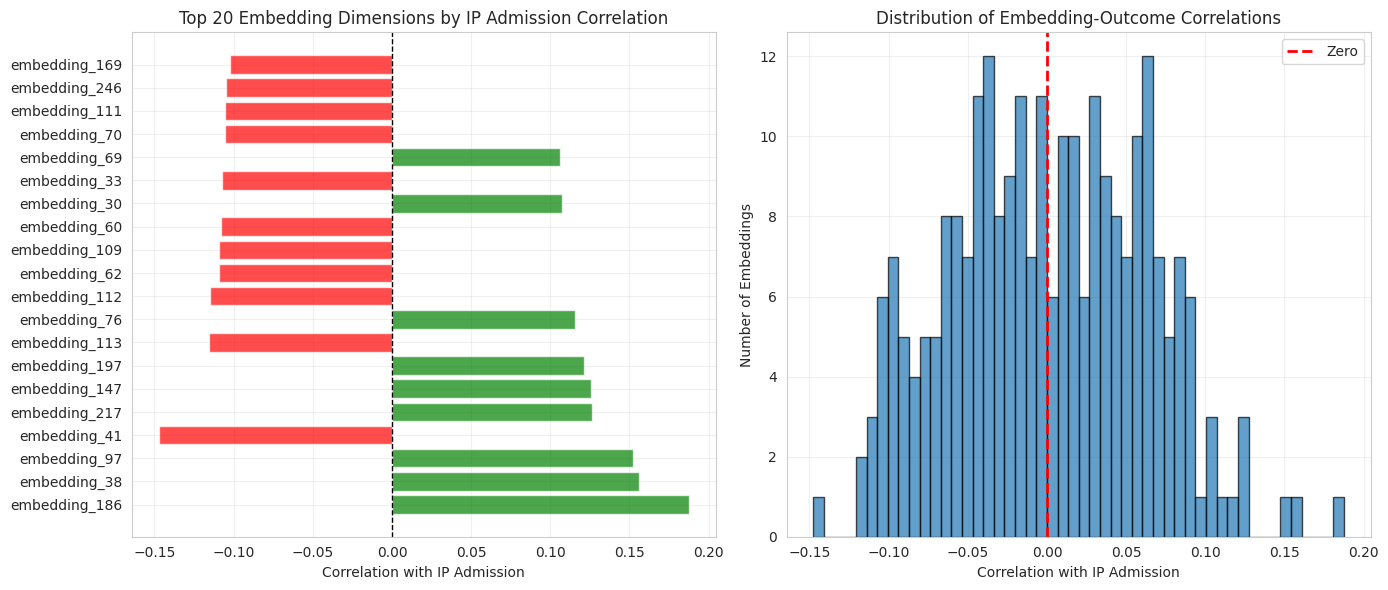


📈 Correlation Summary:
   Max Positive Correlation: 0.1876 (embedding_186)
   Max Negative Correlation: -0.1475
   Mean Absolute Correlation: 0.0514


In [26]:
print(f"🔍 Analyzing correlation between embeddings and {OUTCOME_LABEL}...\n")

# Embedding matrix (N x 256)
X_embeddings = df[embedding_cols].values
y_outcome = df[OUTCOME_COLUMN].values

# Calculate point-biserial correlation for each embedding dimension
correlations = []
for i, col in enumerate(embedding_cols):
    corr, pval = stats.pointbiserialr(y_outcome, df[col])
    correlations.append({
        'embedding': col,
        'dimension': i,
        'correlation': corr,
        'abs_correlation': abs(corr),
        'pval': pval
    })

df_corr = pd.DataFrame(correlations).sort_values('abs_correlation', ascending=False)

print("📊 Top 20 Most Predictive Embedding Dimensions:")
display(df_corr.head(20))

# Plot top correlations
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
top_20 = df_corr.head(20)
colors = ['red' if x < 0 else 'green' for x in top_20['correlation']]
plt.barh(range(len(top_20)), top_20['correlation'], color=colors, alpha=0.7)
plt.yticks(range(len(top_20)), top_20['embedding'])
plt.xlabel(f'Correlation with {OUTCOME_LABEL}')
plt.title(f'Top 20 Embedding Dimensions by {OUTCOME_LABEL} Correlation')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(df_corr['correlation'], bins=50, alpha=0.7, edgecolor='black')
plt.xlabel(f'Correlation with {OUTCOME_LABEL}')
plt.ylabel('Number of Embeddings')
plt.title(f'Distribution of Embedding-Outcome Correlations')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📈 Correlation Summary:")
print(f"   Max Positive Correlation: {df_corr['correlation'].max():.4f} ({df_corr.iloc[0]['embedding']})")
print(f"   Max Negative Correlation: {df_corr['correlation'].min():.4f}")
print(f"   Mean Absolute Correlation: {df_corr['abs_correlation'].mean():.4f}")


### 3.2 Smarter Thresholds: Statistical Significance & Effect Size


🔬 Analyzing correlation thresholds...

📊 Statistical Significance Thresholds:
   Sample size: 836,849
   r critical (p < 0.001, Bonferroni): 0.00360
   r critical (p < 0.0001): 0.00425
   → With 836,849 samples, almost ANY correlation is 'statistically significant'
   → Statistical significance is NOT a good threshold here!

📏 Effect Size Distribution (Using Multiple Thresholds):
   |r| ≥ 0.01 (  Negligible): 234 / 256 ( 91.4%)
   |r| ≥ 0.02 (  Very Small): 201 / 256 ( 78.5%)
   |r| ≥ 0.05 (       Small): 119 / 256 ( 46.5%)
   |r| ≥ 0.10 (Small-Medium):  23 / 256 (  9.0%)
   |r| ≥ 0.20 (      Medium):   0 / 256 (  0.0%)
   |r| ≥ 0.30 (       Large):   0 / 256 (  0.0%)
   |r| ≥ 0.50 (  Very Large):   0 / 256 (  0.0%)

📈 Percentile-Based Thresholds:
   Top 50% of embeddings: |r| ≥ 0.0469 (128 dimensions)
   Top 25% of embeddings: |r| ≥ 0.0732 (64 dimensions)
   Top 10% of embeddings: |r| ≥ 0.0965 (26 dimensions)
   Top  5% of embeddings: |r| ≥ 0.1078 (13 dimensions)
   Top  1% of embeddi

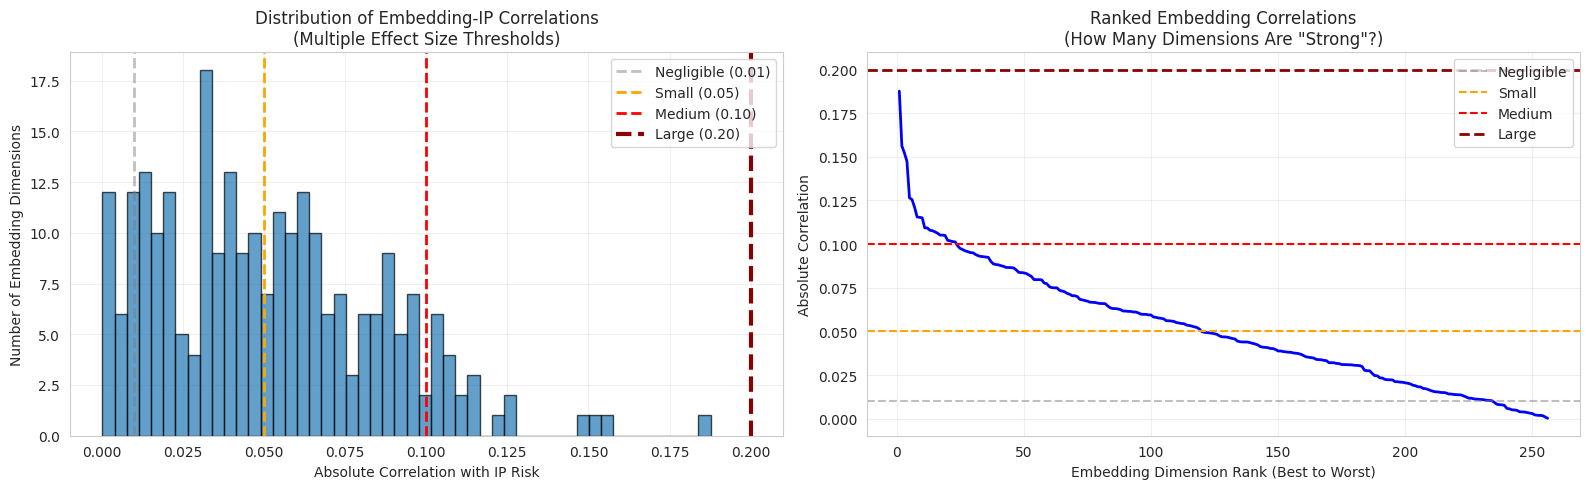


💡 RECOMMENDATIONS:

   For INTERPRETATION:
   - Use |r| ≥ 0.10 as 'meaningfully predictive' → 23 dimensions
   - Use |r| ≥ 0.05 as 'potentially useful' → 119 dimensions

   For FEATURE SELECTION:
   - Top 50 dimensions (top 20%) → r ≥ 0.0835
   - Top 100 dimensions (top 39%) → r ≥ 0.0594

   CONCLUSION:
   - 0.05 is a reasonable 'potentially useful' threshold
   - But 0.10 might be better for 'strongly predictive'
   - Statistical significance (p-value) is meaningless with N=836K


In [27]:
print("🔬 Analyzing correlation thresholds...\n")

# 1. Statistical Significance Threshold
# With large N, even tiny correlations are statistically significant
# Critical r for p < 0.001 with N = 836K: r_critical ≈ 0.011
n_samples = len(df)
r_critical_001 = 3.29 / np.sqrt(n_samples)  # Bonferroni correction for 256 tests
r_critical_0001 = 3.89 / np.sqrt(n_samples)

print(f"📊 Statistical Significance Thresholds:")
print(f"   Sample size: {n_samples:,}")
print(f"   r critical (p < 0.001, Bonferroni): {r_critical_001:.5f}")
print(f"   r critical (p < 0.0001): {r_critical_0001:.5f}")
print(f"   → With {n_samples:,} samples, almost ANY correlation is 'statistically significant'")
print(f"   → Statistical significance is NOT a good threshold here!")

# 2. Effect Size Interpretation (Cohen's guidelines adapted for correlations)
thresholds = {
    'Negligible': 0.01,
    'Very Small': 0.02,
    'Small': 0.05,
    'Small-Medium': 0.10,
    'Medium': 0.20,
    'Large': 0.30,
    'Very Large': 0.50
}

print(f"\n📏 Effect Size Distribution (Using Multiple Thresholds):")
for label, thresh in thresholds.items():
    count = (df_corr['abs_correlation'] >= thresh).sum()
    pct = count / 256 * 100
    print(f"   |r| ≥ {thresh:.2f} ({label:>12}): {count:3d} / 256 ({pct:5.1f}%)")

# 3. Percentile-based approach
print(f"\n📈 Percentile-Based Thresholds:")
percentiles = [50, 75, 90, 95, 99]
for p in percentiles:
    r_thresh = df_corr['abs_correlation'].quantile(p/100)
    count = (df_corr['abs_correlation'] >= r_thresh).sum()
    print(f"   Top {100-p:2d}% of embeddings: |r| ≥ {r_thresh:.4f} ({count} dimensions)")

# 4. Visual: Histogram with various thresholds
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
counts, bins, patches = ax.hist(df_corr['abs_correlation'], bins=50, alpha=0.7, edgecolor='black')
ax.axvline(x=0.01, color='gray', linestyle='--', linewidth=2, label='Negligible (0.01)', alpha=0.5)
ax.axvline(x=0.05, color='orange', linestyle='--', linewidth=2, label='Small (0.05)')
ax.axvline(x=0.10, color='red', linestyle='--', linewidth=2, label='Medium (0.10)')
ax.axvline(x=0.20, color='darkred', linestyle='--', linewidth=3, label='Large (0.20)')
ax.set_xlabel('Absolute Correlation with IP Risk')
ax.set_ylabel('Number of Embedding Dimensions')
ax.set_title('Distribution of Embedding-IP Correlations\n(Multiple Effect Size Thresholds)')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
# Cumulative distribution
sorted_corr = np.sort(df_corr['abs_correlation'].values)[::-1]
ax.plot(range(1, 257), sorted_corr, linewidth=2, color='blue')
ax.axhline(y=0.01, color='gray', linestyle='--', alpha=0.5, label='Negligible')
ax.axhline(y=0.05, color='orange', linestyle='--', label='Small')
ax.axhline(y=0.10, color='red', linestyle='--', label='Medium')
ax.axhline(y=0.20, color='darkred', linestyle='--', linewidth=2, label='Large')
ax.set_xlabel('Embedding Dimension Rank (Best to Worst)')
ax.set_ylabel('Absolute Correlation')
ax.set_title('Ranked Embedding Correlations\n(How Many Dimensions Are "Strong"?)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Recommended thresholds
print(f"\n💡 RECOMMENDATIONS:")
print(f"\n   For INTERPRETATION:")
print(f"   - Use |r| ≥ 0.10 as 'meaningfully predictive' → {(df_corr['abs_correlation'] >= 0.10).sum()} dimensions")
print(f"   - Use |r| ≥ 0.05 as 'potentially useful' → {(df_corr['abs_correlation'] >= 0.05).sum()} dimensions")
print(f"\n   For FEATURE SELECTION:")
print(f"   - Top 50 dimensions (top 20%) → r ≥ {df_corr['abs_correlation'].iloc[49]:.4f}")
print(f"   - Top 100 dimensions (top 39%) → r ≥ {df_corr['abs_correlation'].iloc[99]:.4f}")
print(f"\n   CONCLUSION:")
print(f"   - 0.05 is a reasonable 'potentially useful' threshold")
print(f"   - But 0.10 might be better for 'strongly predictive'")
print(f"   - Statistical significance (p-value) is meaningless with N=836K")


### 3.3 Create Balanced Dataset for UMAP (Address 7% Class Imbalance)


In [28]:
print("🎯 Preparing dataset for UMAP visualization...\n")

if BALANCE_CLASSES:
    print("⚠️ CLASS IMBALANCE DETECTED")
    outcome_prevalence = df[OUTCOME_COLUMN].mean()
    print(f"   Outcome prevalence: {outcome_prevalence*100:.1f}%")
    
    if outcome_prevalence < 0.20 or outcome_prevalence > 0.80:
        print(f"   → Highly imbalanced! (Minority class < 20%)")
        print("\n💡 SOLUTION: Downsample majority class to create 50/50 balance.")
        print("   This gives UMAP equal weight to both classes during optimization.\n")
        
        # Separate classes from the full dataset
        df_outcome_pos = df[df[OUTCOME_COLUMN] == 1]
        df_outcome_neg = df[df[OUTCOME_COLUMN] == 0]
        
        print(f"📊 Original IMBALANCED distribution:")
        print(f"   {OUTCOME_LABEL}=1 (minority): {len(df_outcome_pos):,} ({len(df_outcome_pos)/len(df)*100:.2f}%)")
        print(f"   {OUTCOME_LABEL}=0 (majority): {len(df_outcome_neg):,} ({len(df_outcome_neg)/len(df)*100:.2f}%)")
        print(f"   Ratio: 1:{len(df_outcome_neg)/len(df_outcome_pos):.1f} ← Heavily imbalanced!")
        
        # Downsample majority class to match minority count
        print(f"\n⚙️ Downsampling majority class...")
        minority_size = min(len(df_outcome_pos), len(df_outcome_neg))
        df_outcome_pos_balanced = df_outcome_pos.sample(n=minority_size, random_state=UMAP_RANDOM_STATE, replace=False)
        df_outcome_neg_balanced = df_outcome_neg.sample(n=minority_size, random_state=UMAP_RANDOM_STATE, replace=False)
        
        # Combine for balanced dataset
        df_balanced = pd.concat([df_outcome_pos_balanced, df_outcome_neg_balanced]).sample(frac=1, random_state=UMAP_RANDOM_STATE).reset_index(drop=True)
        
        print(f"\n✅ BALANCED dataset created:")
        print(f"   {OUTCOME_LABEL}=1: {(df_balanced[OUTCOME_COLUMN]==1).sum():,} (50.0%)")
        print(f"   {OUTCOME_LABEL}=0: {(df_balanced[OUTCOME_COLUMN]==0).sum():,} (50.0%)")
        print(f"   Total samples: {len(df_balanced):,}")
        print(f"   Ratio: 1:1 ← Perfectly balanced!")
        
        print(f"\n📉 Dataset reduction: {len(df):,} → {len(df_balanced):,} ({len(df_balanced)/len(df)*100:.1f}% of original)")
        print(f"⚡ Speed benefit: UMAP will run faster with fewer samples")
        print(f"🎨 Visual benefit: Both outcome classes equally visible")
        print(f"📊 Clustering benefit: UMAP optimization not biased toward majority class")
    else:
        print("   → Reasonably balanced (minority class >= 20%)")
        print("   → Using full dataset (no downsampling needed)")
        df_balanced = df.copy()
else:
    print("⚙️ Using FULL dataset (balanced sampling disabled)")
    df_balanced = df.copy()

print(f"\n✅ Ready for UMAP!")
print(f"   Final dataset size: {len(df_balanced):,} samples")
print(f"   Outcome distribution: {df_balanced[OUTCOME_COLUMN].value_counts().to_dict()}")


🎯 Preparing dataset for UMAP visualization...

⚠️ CLASS IMBALANCE DETECTED
   Outcome prevalence: 7.1%
   → Highly imbalanced! (Minority class < 20%)

💡 SOLUTION: Downsample majority class to create 50/50 balance.
   This gives UMAP equal weight to both classes during optimization.

📊 Original IMBALANCED distribution:
   IP Admission=1 (minority): 59,736 (7.14%)
   IP Admission=0 (majority): 777,113 (92.86%)
   Ratio: 1:13.0 ← Heavily imbalanced!

⚙️ Downsampling majority class...

✅ BALANCED dataset created:
   IP Admission=1: 59,736 (50.0%)
   IP Admission=0: 59,736 (50.0%)
   Total samples: 119,472
   Ratio: 1:1 ← Perfectly balanced!

📉 Dataset reduction: 836,849 → 119,472 (14.3% of original)
⚡ Speed benefit: UMAP will run faster with fewer samples
🎨 Visual benefit: Both outcome classes equally visible
📊 Clustering benefit: UMAP optimization not biased toward majority class

✅ Ready for UMAP!
   Final dataset size: 119,472 samples
   Outcome distribution: {np.int64(0): 59736, np.int

---

## 4. Dimensionality Reduction & Visualization

**What this section does:**
- Uses **UMAP** (Uniform Manifold Approximation and Projection) to project 256D embeddings → 2D
- Creates scatter plots colored by outcome (do high-risk patients cluster together?)
- Generates density heatmaps showing "hot spots" of high risk
- Quantifies cluster separation using **Cohen's D** metric

**Why UMAP?**
- Preserves both local and global structure (better than t-SNE or PCA for large datasets)
- Fast and scalable (can handle 100K+ samples)
- Tunable parameters to reveal different patterns

**Key Parameters** (configured in Section 0):
- `n_neighbors`: Higher = more global structure (15-200)
- `min_dist`: Lower = tighter clusters (0.0-0.5)


### 4.1 UMAP: 256D → 2D Projection


In [ ]:
# This cell has been removed - duplicate of cell in Section 3.3
# Balanced sampling is now handled in Section 3.3

In [30]:
print("🗺️ Running UMAP dimensionality reduction (256D → 2D)...")
print("   This may take a few minutes for large datasets...\n")

# Prepare data for UMAP (use balanced dataset from previous cell)
df_viz = df_balanced.copy()
X_viz = df_viz[embedding_cols].values
y_viz = df_viz[OUTCOME_COLUMN].values

print(f"📊 Dataset for UMAP:")
print(f"   Total samples: {len(df_viz):,}")
print(f"   {OUTCOME_LABEL}=1: {y_viz.sum():,} ({y_viz.mean()*100:.1f}%)")
print(f"   {OUTCOME_LABEL}=0: {(y_viz==0).sum():,} ({(y_viz==0).mean()*100:.1f}%)")

# Run UMAP with configured parameters
print(f"\n⏳ Running UMAP...")
print(f"   Parameters: n_neighbors={UMAP_N_NEIGHBORS}, min_dist={UMAP_MIN_DIST}")
print(f"   Estimated time: {len(df_viz)//50000 + 1}-{len(df_viz)//20000 + 2} minutes")

start_time = time.time()
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=UMAP_N_NEIGHBORS,  # ✅ Uses configuration from Section 0
    min_dist=UMAP_MIN_DIST,
    metric='euclidean',
    random_state=UMAP_RANDOM_STATE,
    verbose=True
)

embedding_2d = reducer.fit_transform(X_viz)
umap_time = time.time() - start_time

print(f"\n✅ UMAP complete in {umap_time/60:.1f} minutes ({umap_time:.1f} seconds)")
print(f"   2D embedding shape: {embedding_2d.shape}")

# Add UMAP coordinates to dataframe
df_viz['umap_x'] = embedding_2d[:, 0]
df_viz['umap_y'] = embedding_2d[:, 1]

print(f"✅ Ready for visualization!")


🗺️ Running UMAP dimensionality reduction (256D → 2D)...
   This may take a few minutes for large datasets...

📊 Dataset for UMAP:
   Total samples: 119,472
   IP Admission=1: 59,736 (50.0%)
   IP Admission=0: 59,736 (50.0%)

⏳ Running UMAP...
   Parameters: n_neighbors=100, min_dist=0.1
   Estimated time: 3-7 minutes
UMAP(n_jobs=1, n_neighbors=100, random_state=123, verbose=True)
Tue Jan 27 16:51:25 2026 Construct fuzzy simplicial set
Tue Jan 27 16:51:25 2026 Finding Nearest Neighbors
Tue Jan 27 16:51:25 2026 Building RP forest with 22 trees
Tue Jan 27 16:51:29 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	 3  /  17
	 4  /  17
	Stopping threshold met -- exiting after 4 iterations
Tue Jan 27 16:53:15 2026 Finished Nearest Neighbor Search
Tue Jan 27 16:53:18 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Tue Jan 27 16:55:55 2026 Finished embedding

✅ UMAP complete in 4.5 minutes (270.0 seconds)
   2D embedding shape: (119472, 2)
✅ Ready for visualization!


### 4.2 Visualization: 4-Panel Cluster View ⭐

**What you're looking at (2x2 grid):**

| Top-Left | Top-Right |
|----------|-----------|
| **All Points (Gradient)** | **No-Outcome Cases (Blue)** |
| Overall distribution | Where negative cases concentrate |

| Bottom-Left | Bottom-Right |
|-------------|--------------|
| **Outcome Cases (Red)** | **Risk Heatmap** |
| Where positive cases concentrate | Hot zones (red) = high risk regions |

**Why this layout solves overplotting:**
- With 119K+ points, overlaying red+blue creates a visual mess
- **Side-by-side comparison** lets you see EACH class's density pattern separately
- **Key insight**: Compare Top-Right (blue) vs Bottom-Left (red)
  - If they look **different** → good clustering! ✅
  - If they look **identical** → poor separation ❌

**What to look for:**
- Do blue dots cluster in different regions than red dots?
- Does the heatmap show clear red vs green zones?
- Or do both classes have the same density pattern (poor clustering)?


🎨 Creating visualizations...



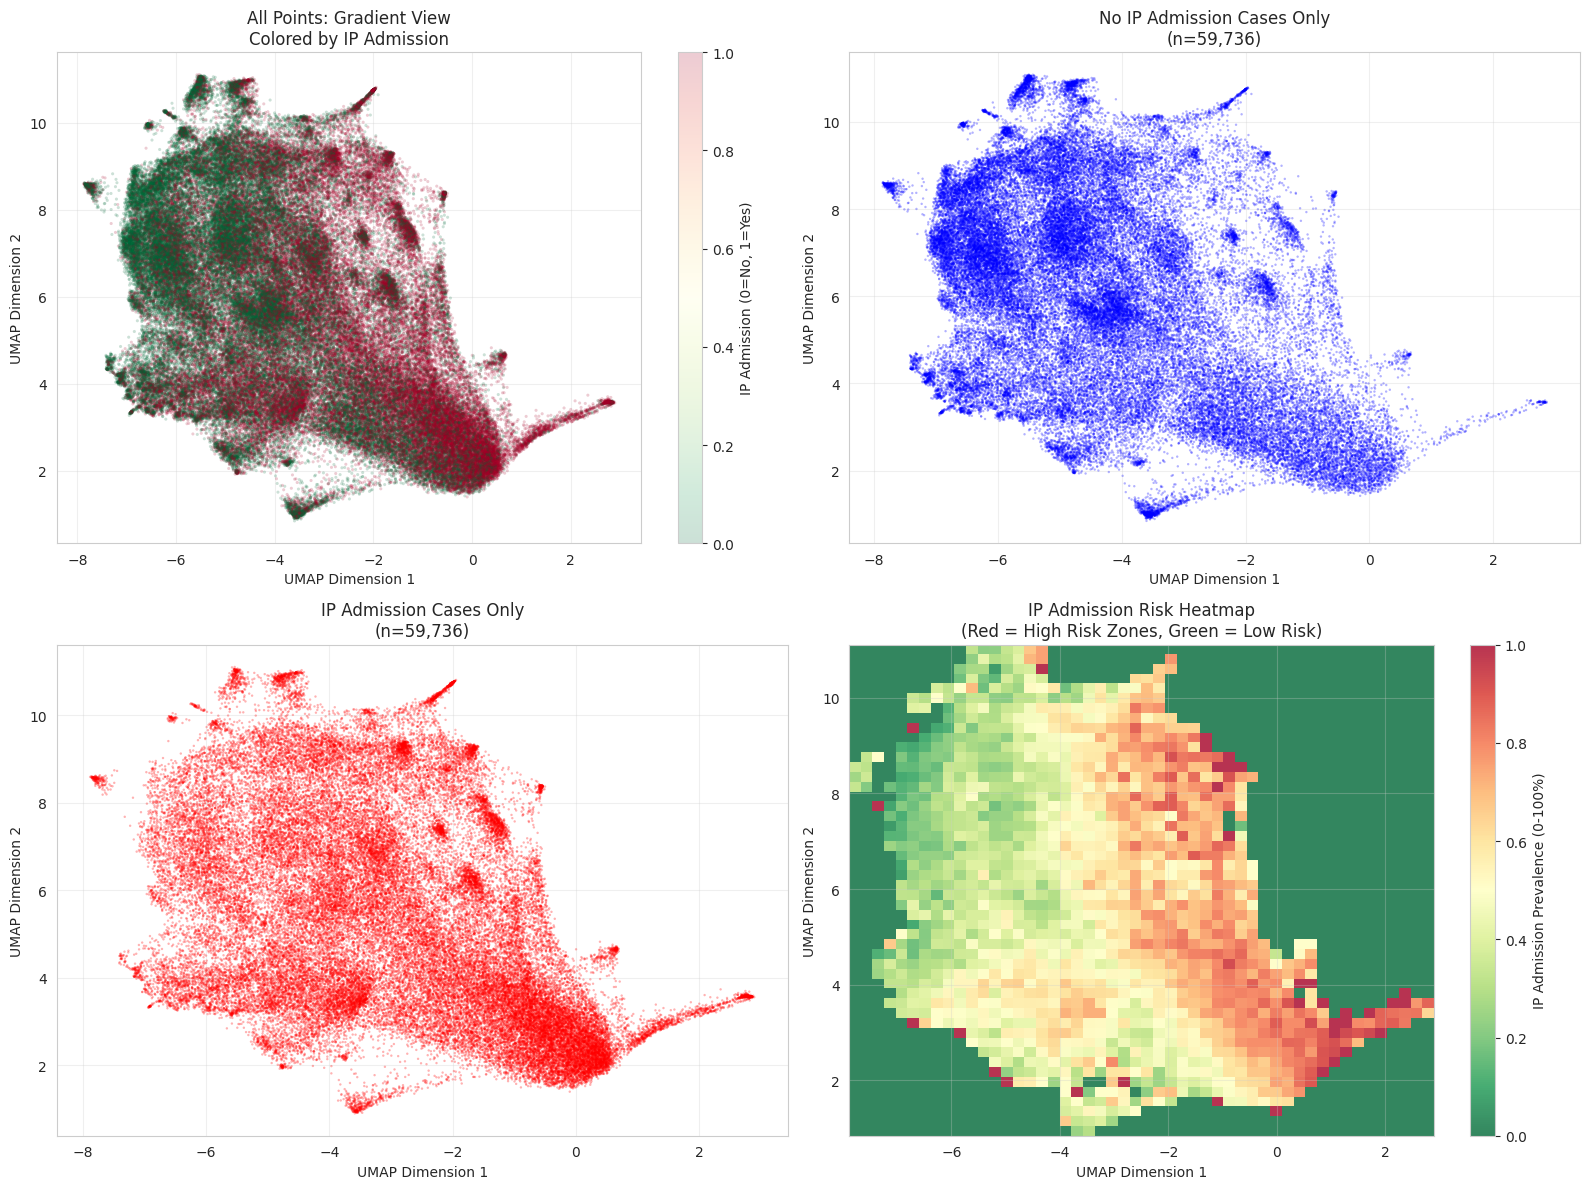

✅ Visualizations complete

💡 How to Interpret the 4-Panel View:

   📊 TOP LEFT (Gradient): Overall distribution of both classes
   📊 TOP RIGHT (Blue): Where No-IP Admission cases cluster
   📊 BOTTOM LEFT (Red): Where IP Admission cases cluster
   📊 BOTTOM RIGHT (Heatmap): Risk 'hot zones' (red) vs 'safe zones' (green)

   ✅ GOOD CLUSTERING: Blue and Red plots show DIFFERENT dense regions
   ❌ POOR CLUSTERING: Blue and Red plots look identical (same dense regions)

   💡 Compare Top-Right vs Bottom-Left:
      - Do they concentrate in DIFFERENT areas? → Embeddings working well!
      - Do they concentrate in the SAME areas? → Limited separation


In [33]:
print("🎨 Creating visualizations...\n")

# Prepare data splits
df_outcome_neg = df_viz[df_viz[OUTCOME_COLUMN] == 0]
df_outcome_pos = df_viz[df_viz[OUTCOME_COLUMN] == 1]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: All points colored by outcome (continuous gradient)
ax = axes[0, 0]
scatter = ax.scatter(
    df_viz['umap_x'], 
    df_viz['umap_y'],
    c=df_viz[OUTCOME_COLUMN],
    cmap='RdYlGn_r',  # Red = high risk (1), Green = low risk (0)
    alpha=0.2,
    s=5,
    edgecolors='none'
)
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.set_title(f'All Points: Gradient View\nColored by {OUTCOME_LABEL}')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label(f'{OUTCOME_LABEL} (0=No, 1=Yes)')
ax.grid(alpha=0.3)

# Plot 2a: NEGATIVE cases only (side-by-side comparison)
ax = axes[0, 1]
ax.scatter(df_outcome_neg['umap_x'], df_outcome_neg['umap_y'], 
           c='blue', alpha=0.3, s=3, edgecolors='none')
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.set_title(f'No {OUTCOME_LABEL} Cases Only\n(n={len(df_outcome_neg):,})')
ax.grid(alpha=0.3)

# Plot 2b: POSITIVE cases only (side-by-side comparison)
ax = axes[1, 0]
ax.scatter(df_outcome_pos['umap_x'], df_outcome_pos['umap_y'], 
           c='red', alpha=0.3, s=3, edgecolors='none')
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.set_title(f'{OUTCOME_LABEL} Cases Only\n(n={len(df_outcome_pos):,})')
ax.grid(alpha=0.3)

# Plot 4: Density heatmap of outcome prevalence (bottom right)
ax = axes[1, 1]

# Create 2D histogram of outcome prevalence across the embedding space
h, xedges, yedges = np.histogram2d(
    df_viz['umap_x'], 
    df_viz['umap_y'], 
    bins=50
)

h_outcome_pos, _, _ = np.histogram2d(
    df_outcome_pos['umap_x'], 
    df_outcome_pos['umap_y'], 
    bins=[xedges, yedges]
)

# Calculate outcome prevalence per bin
with np.errstate(divide='ignore', invalid='ignore'):
    outcome_prevalence = h_outcome_pos / h
    outcome_prevalence = np.nan_to_num(outcome_prevalence, nan=0)

im = ax.imshow(
    outcome_prevalence.T, 
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    cmap='RdYlGn_r',
    aspect='auto',
    alpha=0.8,
    vmin=0,
    vmax=1
)

ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.set_title(f'{OUTCOME_LABEL} Risk Heatmap\n(Red = High Risk Zones, Green = Low Risk)')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(f'{OUTCOME_LABEL} Prevalence (0-100%)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualizations complete")
print(f"\n💡 How to Interpret the 4-Panel View:")
print(f"\n   📊 TOP LEFT (Gradient): Overall distribution of both classes")
print(f"   📊 TOP RIGHT (Blue): Where No-{OUTCOME_LABEL} cases cluster")
print(f"   📊 BOTTOM LEFT (Red): Where {OUTCOME_LABEL} cases cluster")
print(f"   📊 BOTTOM RIGHT (Heatmap): Risk 'hot zones' (red) vs 'safe zones' (green)")
print(f"\n   ✅ GOOD CLUSTERING: Blue and Red plots show DIFFERENT dense regions")
print(f"   ❌ POOR CLUSTERING: Blue and Red plots look identical (same dense regions)")
print(f"\n   💡 Compare Top-Right vs Bottom-Left:")
print(f"      - Do they concentrate in DIFFERENT areas? → Embeddings working well!")
print(f"      - Do they concentrate in the SAME areas? → Limited separation")


### 4.3 Quantify Cluster Separation

**What this calculates:**
- **Centroid Distance**: How far apart are the two outcome groups in 2D space?
- **Within-Group Variance**: How spread out is each group?
- **Cohen's D**: Standardized effect size (distance / pooled std deviation)

**Cohen's D Interpretation:**
- **< 0.2**: Negligible separation
- **0.2-0.5**: Small effect
- **0.5-0.8**: Medium effect (noticeable clustering) ✅
- **> 0.8**: Large effect (strong clustering)


In [34]:
print(f"📊 Quantifying cluster separation for {OUTCOME_LABEL}...\n")

# Split by outcome
df_outcome_neg = df_viz[df_viz[OUTCOME_COLUMN] == 0]
df_outcome_pos = df_viz[df_viz[OUTCOME_COLUMN] == 1]

# Calculate centroids (mean position in 2D space)
centroid_neg = df_outcome_neg[['umap_x', 'umap_y']].mean().values
centroid_pos = df_outcome_pos[['umap_x', 'umap_y']].mean().values

centroid_distance = np.linalg.norm(centroid_pos - centroid_neg)

print(f"🎯 Cluster Centroids:")
print(f"   {OUTCOME_LABEL}=0 Centroid: ({centroid_neg[0]:.3f}, {centroid_neg[1]:.3f})")
print(f"   {OUTCOME_LABEL}=1 Centroid: ({centroid_pos[0]:.3f}, {centroid_pos[1]:.3f})")
print(f"   Euclidean Distance: {centroid_distance:.3f}")

# Within-group variance (how spread out is each cluster?)
var_neg = df_outcome_neg[['umap_x', 'umap_y']].var().mean()
var_pos = df_outcome_pos[['umap_x', 'umap_y']].var().mean()

print(f"\n📏 Within-Group Variance:")
print(f"   {OUTCOME_LABEL}=0 Variance: {var_neg:.3f}")
print(f"   {OUTCOME_LABEL}=1 Variance: {var_pos:.3f}")

# Cohen's D effect size (standardized distance between groups)
pooled_std = np.sqrt((var_neg + var_pos) / 2)
cohens_d = centroid_distance / pooled_std

print(f"\n📈 Effect Size (Cohen's D): {cohens_d:.3f}")
if cohens_d < 0.2:
    interpretation = "Negligible (no clustering)"
elif cohens_d < 0.5:
    interpretation = "Small effect"
elif cohens_d < 0.8:
    interpretation = "Medium effect (noticeable separation)"
else:
    interpretation = "Large effect (strong clustering)"
print(f"   Interpretation: {interpretation}")

print(f"\n💡 What this means:")
if cohens_d >= 0.5:
    print(f"   ✅ Embeddings meaningfully separate {OUTCOME_LABEL} groups!")
    print(f"   ✅ Transformer captures clinical patterns relevant to {OUTCOME_LABEL}")
    print(f"   ✅ Consider using embeddings in predictive models")
else:
    print(f"   ⚠️ Limited separation between {OUTCOME_LABEL} groups")
    print(f"   ⚠️ Embeddings may not strongly capture this specific outcome")
    print(f"   ⚠️ They may still add value in combination with other features")


📊 Quantifying cluster separation for IP Admission...

🎯 Cluster Centroids:
   IP Admission=0 Centroid: (-4.230, 6.046)
   IP Admission=1 Centroid: (-2.903, 5.334)
   Euclidean Distance: 1.506

📏 Within-Group Variance:
   IP Admission=0 Variance: 4.531
   IP Admission=1 Variance: 4.973

📈 Effect Size (Cohen's D): 0.691
   Interpretation: Medium effect (noticeable separation)

💡 What this means:
   ✅ Embeddings meaningfully separate IP Admission groups!
   ✅ Transformer captures clinical patterns relevant to IP Admission
   ✅ Consider using embeddings in predictive models


---

## 5. 📊 Summary: Key Findings

**This is your main takeaway section!**  
Review this after running the analysis to understand if your embeddings are valuable.


In [35]:
print("="*80)
print(f"🎯 KEY FINDINGS: Do Embeddings Cluster by {OUTCOME_LABEL}?")
print("="*80)

print(f"\n1️⃣ CLUSTER SEPARATION (UMAP 2D):")
print(f"   - Embedding Source: {EMBEDDING_NAME}")
print(f"   - Centroid Distance: {centroid_distance:.3f}")
print(f"   - Cohen's D Effect Size: {cohens_d:.3f} ({interpretation})")
print(f"   - Interpretation: {'✅ Embeddings separate outcome groups well' if cohens_d > 0.5 else '⚠️ Limited separation' if cohens_d > 0.3 else '❌ Minimal/no separation'}")

print(f"\n2️⃣ PREDICTIVE EMBEDDING DIMENSIONS:")
top_emb = df_corr.iloc[0]
print(f"   - Most Predictive: {top_emb['embedding']} (r={top_emb['correlation']:.4f})")
print(f"   - Mean Abs Correlation: {df_corr['abs_correlation'].mean():.4f}")
print(f"   - Strong Predictors (|r| > {CORRELATION_THRESHOLD}): {(df_corr['abs_correlation'] > CORRELATION_THRESHOLD).sum()} / {len(embedding_cols)} dimensions")
print(f"   - Very Strong Predictors (|r| > 0.10): {(df_corr['abs_correlation'] > 0.10).sum()} / {len(embedding_cols)} dimensions")

print(f"\n3️⃣ BUSINESS IMPLICATIONS:")
if cohens_d >= 0.8:
    print(f"   ✅✅ Embeddings are EXCEPTIONALLY VALUABLE for {OUTCOME_LABEL} prediction")
    print(f"   ✅ Very clear visual separation between outcome groups")
    print(f"   ✅ Embeddings likely outperform baseline features alone")
    print(f"   ✅ Strong candidate for standalone risk stratification")
elif cohens_d >= 0.5:
    print(f"   ✅ Embeddings are HIGHLY VALUABLE for {OUTCOME_LABEL} prediction")
    print(f"   ✅ Clear visual separation between outcome groups")
    print(f"   ✅ Consider using embeddings + baseline features (hybrid model)")
    print(f"   ✅ Embeddings add meaningful signal beyond demographics")
elif cohens_d >= 0.3:
    print(f"   ⚠️ Embeddings provide MODERATE value for {OUTCOME_LABEL} prediction")
    print(f"   ⚠️ Some visual separation, but not dramatic")
    print(f"   ⚠️ Best used in combination with baseline features")
    print(f"   ⚠️ May improve model performance incrementally")
else:
    print(f"   ❌ Embeddings show LIMITED clustering by {OUTCOME_LABEL}")
    print(f"   ❌ Minimal visual separation between outcome groups")
    print(f"   ❌ May capture other clinical patterns, but not this specific outcome")
    print(f"   ❌ Consider: (1) Different outcome? (2) Different embedding architecture?")

print(f"\n4️⃣ NEXT STEPS:")
print(f"   📊 Review the visualizations in Section 4.2 above")
print(f"   📊 Check the density heatmap - are there 'hot spots' of {OUTCOME_LABEL}?")
print(f"   📊 Train a predictive model with embeddings to quantify actual performance lift")
if ALTERNATIVE_EMBEDDING_TABLE:
    print(f"   📊 Try Section 6 to compare with alternative embedding: {ALTERNATIVE_EMBEDDING_NAME}")

print(f"\n{'='*80}")


🎯 KEY FINDINGS: Do Embeddings Cluster by IP Admission?

1️⃣ CLUSTER SEPARATION (UMAP 2D):
   - Embedding Source: opt_config
   - Centroid Distance: 1.506
   - Cohen's D Effect Size: 0.691 (Medium effect (noticeable separation))
   - Interpretation: ✅ Embeddings separate outcome groups well

2️⃣ PREDICTIVE EMBEDDING DIMENSIONS:
   - Most Predictive: embedding_186 (r=0.1876)
   - Mean Abs Correlation: 0.0514
   - Strong Predictors (|r| > 0.05): 119 / 256 dimensions
   - Very Strong Predictors (|r| > 0.10): 23 / 256 dimensions

3️⃣ BUSINESS IMPLICATIONS:
   ✅ Embeddings are HIGHLY VALUABLE for IP Admission prediction
   ✅ Clear visual separation between outcome groups
   ✅ Consider using embeddings + baseline features (hybrid model)
   ✅ Embeddings add meaningful signal beyond demographics

4️⃣ NEXT STEPS:
   📊 Review the visualizations in Section 4.2 above
   📊 Check the density heatmap - are there 'hot spots' of IP Admission?
   📊 Train a predictive model with embeddings to quantify act

---

## 6. 🔄 **[OPTIONAL]** Compare Alternative Embeddings

**⚠️ This section is OPTIONAL** - Skip if you only want to analyze one embedding source.

**Purpose:**  
Compare multiple embedding architectures side-by-side to determine which produces better clustering.

**When to use this:**
- You have multiple transformer models/architectures to evaluate
- You want to A/B test embeddings before deploying to production
- You're optimizing embedding architecture for a specific outcome

**How to use:**
1. Configure `ALTERNATIVE_EMBEDDING_TABLE` in Section 0
2. Run cells in this section
3. Compare Cohen's D values between primary and alternative embeddings

**Current Configuration:**
- Primary: `{EMBEDDING_NAME}`
- Alternative: `{ALTERNATIVE_EMBEDDING_NAME}` (if configured)


In [14]:
print("="*80)
print("🔄 COMPARING ALTERNATIVE EMBEDDING SOURCE")
print("="*80)

print("\n📊 Current embedding (for comparison):")
print("   Source: opt_config (dense_baseline)")
print(f"   Cohen's D: {cohens_d:.3f} (Medium)")
print(f"   Strong predictors: {(df_corr['abs_correlation'] > 0.05).sum()} / 256 dimensions")

print("\n🆕 Testing alternative embedding:")
print("   Source: exp2b_flash_learned_pool_v2")
print("   Architecture: Flash attention + learned pooling")
print("   Loading embeddings...")


🔄 COMPARING ALTERNATIVE EMBEDDING SOURCE

📊 Current embedding (for comparison):
   Source: opt_config (dense_baseline)
   Cohen's D: 0.696 (Medium)
   Strong predictors: 119 / 256 dimensions

🆕 Testing alternative embedding:
   Source: exp2b_flash_learned_pool_v2
   Architecture: Flash attention + learned pooling
   Loading embeddings...


In [15]:
# Load alternative embeddings
embeddings_sql_alt = """
    SELECT *
    FROM `edp-prod-storage.edp_ent_sdoheir_cns.a964286_te4exp_3lob_exp_round5_v2_exp2b_flash_learned_pool_v2_medicare_all_sample_embedding`
"""

start_time = time.time()
df_embeddings_alt = client.query(embeddings_sql_alt).to_dataframe()
load_time = time.time() - start_time

print(f"\n✅ Alternative embeddings loaded in {load_time:.1f} seconds")
print(f"   Shape: {df_embeddings_alt.shape}")
print(f"   Columns: {df_embeddings_alt.columns[:5].tolist()}...")

# Fix data types for joining
df_embeddings_alt['individual_id'] = df_embeddings_alt['individual_id'].astype(str)
df_embeddings_alt['index_dt'] = pd.to_datetime(df_embeddings_alt['index_dt']).dt.date

# Join with IP outcomes
df_alt = df_embeddings_alt.merge(
    df_baseline,
    on=['individual_id', 'index_dt'],
    how='inner'
)

print(f"\n✅ Joined dataset: {df_alt.shape[0]:,} rows")
print(f"   IP Prevalence: {df_alt['ip6'].mean()*100:.2f}%")

# Extract embedding columns
embedding_cols_alt = [col for col in df_alt.columns if col.startswith('embedding_')]
print(f"   Embedding dimensions: {len(embedding_cols_alt)}")



✅ Alternative embeddings loaded in 24.4 seconds
   Shape: (836844, 260)
   Columns: ['individual_id', 'index_dt', 'embedding_0', 'embedding_1', 'embedding_2']...

✅ Joined dataset: 836,849 rows
   IP Prevalence: 7.14%
   Embedding dimensions: 256


### 6.1 Correlation Analysis: Alternative Embeddings


In [16]:
print("🔍 Analyzing correlation between ALTERNATIVE embeddings and IP risk...\n")

# Embedding matrix (N x 256)
X_embeddings_alt = df_alt[embedding_cols_alt].values
y_outcome_alt = df_alt['ip6'].values

# Calculate point-biserial correlation for each embedding dimension
correlations_alt = []
for i, col in enumerate(embedding_cols_alt):
    corr, pval = stats.pointbiserialr(y_outcome_alt, df_alt[col])
    correlations_alt.append({
        'embedding': col,
        'dimension': i,
        'correlation': corr,
        'p_value': pval,
        'abs_correlation': abs(corr)
    })

df_corr_alt = pd.DataFrame(correlations_alt).sort_values('abs_correlation', ascending=False)

print(f"📊 Top 5 most predictive embedding dimensions:")
print(df_corr_alt[['embedding', 'correlation', 'abs_correlation']].head())

print(f"\n📊 Summary Statistics:")
print(f"   Mean absolute correlation: {df_corr_alt['abs_correlation'].mean():.4f}")
print(f"   Max absolute correlation: {df_corr_alt['abs_correlation'].max():.4f}")
print(f"   Strong predictors (|r| > 0.05): {(df_corr_alt['abs_correlation'] > 0.05).sum()} / {len(df_corr_alt)}")
print(f"   Medium predictors (|r| > 0.10): {(df_corr_alt['abs_correlation'] > 0.10).sum()} / {len(df_corr_alt)}")

print(f"\n🔄 COMPARISON:")
print(f"   opt_config mean |r|: {df_corr['abs_correlation'].mean():.4f}")
print(f"   exp2b_flash mean |r|: {df_corr_alt['abs_correlation'].mean():.4f}")
diff = df_corr_alt['abs_correlation'].mean() - df_corr['abs_correlation'].mean()
print(f"   Difference: {diff:+.4f} {'✅ BETTER' if diff > 0 else '❌ WORSE' if diff < 0 else '➖ SAME'}")


🔍 Analyzing correlation between ALTERNATIVE embeddings and IP risk...

📊 Top 5 most predictive embedding dimensions:
         embedding  correlation  abs_correlation
106  embedding_106    -0.153458         0.153458
59    embedding_59    -0.152139         0.152139
144  embedding_144    -0.149802         0.149802
9      embedding_9    -0.147087         0.147087
226  embedding_226    -0.143324         0.143324

📊 Summary Statistics:
   Mean absolute correlation: 0.0652
   Max absolute correlation: 0.1535
   Strong predictors (|r| > 0.05): 158 / 256
   Medium predictors (|r| > 0.10): 59 / 256

🔄 COMPARISON:
   opt_config mean |r|: 0.0514
   exp2b_flash mean |r|: 0.0652
   Difference: +0.0138 ✅ BETTER


### 6.2 Create Balanced Dataset (Alternative Embeddings)


In [17]:
print("🎯 Creating BALANCED dataset for alternative embeddings...\n")

# Separate classes
df_ip_alt = df_alt[df_alt['ip6'] == 1]
df_no_ip_alt = df_alt[df_alt['ip6'] == 0]

print(f"📊 Original distribution:")
print(f"   IP cases: {len(df_ip_alt):,} ({len(df_ip_alt)/len(df_alt)*100:.2f}%)")
print(f"   No-IP cases: {len(df_no_ip_alt):,} ({len(df_no_ip_alt)/len(df_alt)*100:.2f}%)")

# Downsample non-IP to match IP count
df_no_ip_balanced_alt = df_no_ip_alt.sample(n=len(df_ip_alt), random_state=123)

# Combine for balanced dataset
df_balanced_alt = pd.concat([df_ip_alt, df_no_ip_balanced_alt]).sample(frac=1, random_state=123).reset_index(drop=True)

print(f"\n✅ BALANCED dataset created:")
print(f"   Total samples: {len(df_balanced_alt):,}")
print(f"   IP cases: {(df_balanced_alt['ip6']==1).sum():,} (50.0%)")
print(f"   No-IP cases: {(df_balanced_alt['ip6']==0).sum():,} (50.0%)")

# Prepare for UMAP
df_viz_alt = df_balanced_alt.copy()
X_viz_alt = df_viz_alt[embedding_cols_alt].values
y_viz_alt = df_viz_alt['ip6'].values

print(f"\n✅ Ready for UMAP!")


🎯 Creating BALANCED dataset for alternative embeddings...

📊 Original distribution:
   IP cases: 59,736 (7.14%)
   No-IP cases: 777,113 (92.86%)

✅ BALANCED dataset created:
   Total samples: 119,472
   IP cases: 59,736 (50.0%)
   No-IP cases: 59,736 (50.0%)

✅ Ready for UMAP!


### 6.3 UMAP Projection (Alternative Embeddings)


In [18]:
print("🗺️ Running UMAP on ALTERNATIVE embeddings...\n")

print(f"📊 Dataset:")
print(f"   Samples: {len(df_viz_alt):,}")
print(f"   IP cases: {y_viz_alt.sum():,} (50.0%)")
print(f"   Parameters: n_neighbors=100, min_dist=0.1")

start_time = time.time()
reducer_alt = umap.UMAP(
    n_components=2,
    n_neighbors=100,
    min_dist=0.1,
    metric='euclidean',
    random_state=123,
    verbose=True
)

embedding_2d_alt = reducer_alt.fit_transform(X_viz_alt)
umap_time_alt = time.time() - start_time

print(f"\n✅ UMAP complete in {umap_time_alt/60:.1f} minutes ({umap_time_alt:.1f} seconds)")
print(f"   2D embedding shape: {embedding_2d_alt.shape}")

# Add to dataframe
df_viz_alt['umap_x'] = embedding_2d_alt[:, 0]
df_viz_alt['umap_y'] = embedding_2d_alt[:, 1]

print(f"\n📊 Ready for visualization!")


🗺️ Running UMAP on ALTERNATIVE embeddings...

📊 Dataset:
   Samples: 119,472
   IP cases: 59,736 (50.0%)
   Parameters: n_neighbors=100, min_dist=0.1
UMAP(n_jobs=1, n_neighbors=100, random_state=123, verbose=True)
Tue Jan 27 15:42:54 2026 Construct fuzzy simplicial set
Tue Jan 27 15:42:54 2026 Finding Nearest Neighbors
Tue Jan 27 15:42:54 2026 Building RP forest with 22 trees
Tue Jan 27 15:42:57 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	 3  /  17
	Stopping threshold met -- exiting after 3 iterations
Tue Jan 27 15:44:19 2026 Finished Nearest Neighbor Search
Tue Jan 27 15:44:24 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Tue Jan 27 16:00:17 2026 Finished embedding

✅ UMAP complete in 17.4 minutes (1042.9 seconds)
   2D embedding shape: (119472, 2)

📊 Ready for visualization!


### 6.4 Quantify Cluster Separation (Alternative Embeddings)


In [19]:
print("📊 Quantifying cluster separation for ALTERNATIVE embeddings...\n")

# Split by outcome
df_no_ip_viz_alt = df_viz_alt[df_viz_alt['ip6'] == 0]
df_ip_viz_alt = df_viz_alt[df_viz_alt['ip6'] == 1]

# Calculate centroids
centroid_no_ip_alt = df_no_ip_viz_alt[['umap_x', 'umap_y']].mean().values
centroid_ip_alt = df_ip_viz_alt[['umap_x', 'umap_y']].mean().values
centroid_distance_alt = np.linalg.norm(centroid_ip_alt - centroid_no_ip_alt)

print(f"🎯 Cluster Centroids:")
print(f"   No-IP Centroid: ({centroid_no_ip_alt[0]:.3f}, {centroid_no_ip_alt[1]:.3f})")
print(f"   IP Centroid: ({centroid_ip_alt[0]:.3f}, {centroid_ip_alt[1]:.3f})")
print(f"   Euclidean Distance: {centroid_distance_alt:.3f}")

# Within-group variance
var_no_ip_alt = df_no_ip_viz_alt[['umap_x', 'umap_y']].var().mean()
var_ip_alt = df_ip_viz_alt[['umap_x', 'umap_y']].var().mean()

print(f"\n📏 Within-Group Variance:")
print(f"   No-IP Variance: {var_no_ip_alt:.3f}")
print(f"   IP Variance: {var_ip_alt:.3f}")

# Cohen's D effect size
pooled_std_alt = np.sqrt((var_no_ip_alt + var_ip_alt) / 2)
cohens_d_alt = centroid_distance_alt / pooled_std_alt

print(f"\n📈 Effect Size (Cohen's D): {cohens_d_alt:.3f}")
if cohens_d_alt < 0.2:
    interpretation_alt = "Small (minimal separation)"
elif cohens_d_alt < 0.5:
    interpretation_alt = "Small-Medium"
elif cohens_d_alt < 0.8:
    interpretation_alt = "Medium (noticeable separation)"
else:
    interpretation_alt = "Large (strong separation)"
print(f"   Interpretation: {interpretation_alt}")

# COMPARISON
print(f"\n" + "="*80)
print(f"🔄 COMPARISON: opt_config vs exp2b_flash")
print(f"="*80)
print(f"\n📊 Centroid Distance:")
print(f"   opt_config: {centroid_distance:.3f}")
print(f"   exp2b_flash: {centroid_distance_alt:.3f}")
diff_dist = centroid_distance_alt - centroid_distance
print(f"   Difference: {diff_dist:+.3f} ({abs(diff_dist/centroid_distance)*100:+.1f}%)")

print(f"\n📊 Cohen's D (KEY METRIC):")
print(f"   opt_config: {cohens_d:.3f} ({interpretation})")
print(f"   exp2b_flash: {cohens_d_alt:.3f} ({interpretation_alt})")
diff_cohens = cohens_d_alt - cohens_d
pct_change = (diff_cohens / cohens_d) * 100
print(f"   Difference: {diff_cohens:+.3f} ({pct_change:+.1f}%)")

if diff_cohens > 0.05:
    winner = "✅ exp2b_flash WINS! Better clustering"
elif diff_cohens < -0.05:
    winner = "✅ opt_config WINS! Better clustering"
else:
    winner = "➖ TIE: Similar clustering performance"
    
print(f"\n🏆 WINNER: {winner}")


📊 Quantifying cluster separation for ALTERNATIVE embeddings...

🎯 Cluster Centroids:
   No-IP Centroid: (51.876, 0.126)
   IP Centroid: (52.511, 1.191)
   Euclidean Distance: 1.239

📏 Within-Group Variance:
   No-IP Variance: 3.697
   IP Variance: 3.781

📈 Effect Size (Cohen's D): 0.641
   Interpretation: Medium (noticeable separation)

🔄 COMPARISON: opt_config vs exp2b_flash

📊 Centroid Distance:
   opt_config: 1.528
   exp2b_flash: 1.239
   Difference: -0.289 (+18.9%)

📊 Cohen's D (KEY METRIC):
   opt_config: 0.696 (Medium effect (noticeable separation))
   exp2b_flash: 0.641 (Medium (noticeable separation))
   Difference: -0.055 (-7.9%)

🏆 WINNER: ✅ opt_config WINS! Better clustering


---

## 7. 📚 **Appendix: Customization Guide**

**This section provides detailed instructions for customizing this notebook for your own analysis.**

### 🔧 Quick Start Checklist

To adapt this notebook for your own data:

1. **✅ Update Configuration (Section 0)**
   - `EMBEDDING_TABLE`: Your transformer embedding table
   - `OUTCOME_TABLE`: Your outcome/label table
   - `OUTCOME_COLUMN`: Your binary outcome column name
   - `JOIN_KEYS`: How your tables join (usually `['individual_id', 'index_dt']`)

2. **✅ Run All Cells**
   - Menu → Run → Run All Cells
   - Estimated time: 5-20 minutes depending on dataset size

3. **✅ Review Results**
   - Jump to Section 5 for key findings
   - Review visualizations in Section 4.2
   - Check Cohen's D metric (target: > 0.5 for meaningful clustering)

---

### 🎛️ Advanced Customization

#### **Tuning UMAP Parameters**

If your visualizations don't show clear clusters, try adjusting:

```python
# In Section 0:
UMAP_N_NEIGHBORS = 100  # Try 15-200
UMAP_MIN_DIST = 0.1     # Try 0.0-0.5
```

**Effect of parameters:**
- **`n_neighbors`**: Higher → more global structure, lower → more local clusters
  - Try 15-50 for local detail
  - Try 100-200 for overall patterns
- **`min_dist`**: Lower → tighter clusters, higher → more spread out
  - Try 0.0-0.1 for tight clusters
  - Try 0.3-0.5 for looser, more separated groups

#### **Handling Different Outcomes**

This notebook works with **binary outcomes only** (0/1).  
For multi-class outcomes:
- Modify visualization code to use different colors per class
- Calculate Cohen's D for each pair of classes
- Consider using PCA or t-SNE instead of UMAP for >2 classes

#### **Balanced Sampling Control**

```python
# In Section 0:
BALANCE_CLASSES = True   # Downsample majority class (recommended for <20% prevalence)
BALANCE_CLASSES = False  # Use full dataset (if classes are reasonably balanced)
```

---

### 🐛 Troubleshooting

#### **Problem: Join returns 0 rows**

**Symptoms:** Section 2.3 shows "Joined dataset: 0 rows"

**Solutions:**
1. Check if `JOIN_KEYS` are correct
   ```python
   print(df_embeddings[JOIN_KEYS].head())
   print(df_baseline[JOIN_KEYS].head())
   ```
2. Verify data type mismatches (common issue!)
   - Look at the data type conversion output in Section 2.3
   - Manually inspect sample values
3. Check if tables have overlapping date ranges

#### **Problem: UMAP is too slow**

**Symptoms:** UMAP takes > 30 minutes

**Solutions:**
1. Enable balanced sampling to reduce dataset size
2. Use a random sample for exploration:
   ```python
   df_balanced = df_balanced.sample(n=50000, random_state=123)
   ```
3. Reduce `n_neighbors` (faster but less accurate)

#### **Problem: No visual clustering**

**Symptoms:** Scatter plot shows mixed colors everywhere

**Possible causes:**
1. **Embeddings don't capture this outcome** → Try different outcome or embedding source
2. **UMAP parameters not optimal** → Increase `n_neighbors` to 150-200
3. **Outcome is truly random** → Check correlation analysis in Section 3.1

#### **Problem: Cohen's D is very low (< 0.2)**

**Interpretation:** Embeddings don't separate this outcome well

**Next steps:**
1. **Try alternative embedding architecture** (Section 6)
2. **Check correlation analysis** (Section 3.1) - are ANY dimensions predictive?
3. **Try a different outcome** - embeddings may capture other clinical patterns
4. **Re-train transformer** with this specific outcome as auxiliary task

---

### 📊 Expected Runtime

| Dataset Size | Balanced Sampling | Estimated Time |
|--------------|-------------------|----------------|
| < 50K rows   | Not needed        | 2-5 minutes    |
| 50-200K rows | Recommended       | 5-10 minutes   |
| 200K-1M rows | Strongly recommended | 10-20 minutes |
| > 1M rows    | Required          | 20-60 minutes  |

**Bottlenecks:**
- BigQuery data loading: ~30-60 seconds per table
- UMAP projection: ~5 seconds per 10K samples (scales quadratically)
- Visualization: ~10 seconds (regardless of size)

---

### 🔬 Understanding the Metrics

#### **Point-Biserial Correlation (Section 3)**
- Measures: Linear relationship between embedding dimension and binary outcome
- Range: -1 to +1
- Interpretation: 
  - |r| < 0.05: Negligible
  - |r| 0.05-0.10: Small but potentially useful
  - |r| > 0.10: Meaningfully predictive

#### **Cohen's D (Section 4)**
- Measures: Standardized distance between two group centroids
- Formula: `(mean1 - mean2) / pooled_std`
- Interpretation:
  - d < 0.2: Negligible effect
  - d = 0.2-0.5: Small effect
  - d = 0.5-0.8: Medium effect (✅ target for embedding quality)
  - d > 0.8: Large effect (embeddings very predictive)

#### **UMAP Coordinates**
- **Not directly interpretable** - only relative positions matter
- Preserves: Neighborhood relationships (nearby points are similar)
- Does NOT preserve: Absolute distances, angles, or densities

---

### 📖 Further Reading

**UMAP Documentation:**
- Official docs: https://umap-learn.readthedocs.io/
- Parameter guide: https://umap-learn.readthedocs.io/en/latest/parameters.html

**Effect Size Interpretation:**
- Cohen's D: https://en.wikipedia.org/wiki/Effect_size#Cohen's_d
- Point-biserial correlation: https://en.wikipedia.org/wiki/Point-biserial_correlation_coefficient

**Transformer Embeddings:**
- BERT embeddings: https://arxiv.org/abs/1810.04805
- Clinical transformers: Review your team's internal documentation

---

**Questions or Issues?**  
Contact: Pritha Ghosh (pritha.ghosh@cvshealth.com)  
Team: Clinical & Social Determinants Intelligence (CSDI)


### 6.5 Visualization: Alternative Embeddings


🎨 Creating visualizations for ALTERNATIVE embeddings...



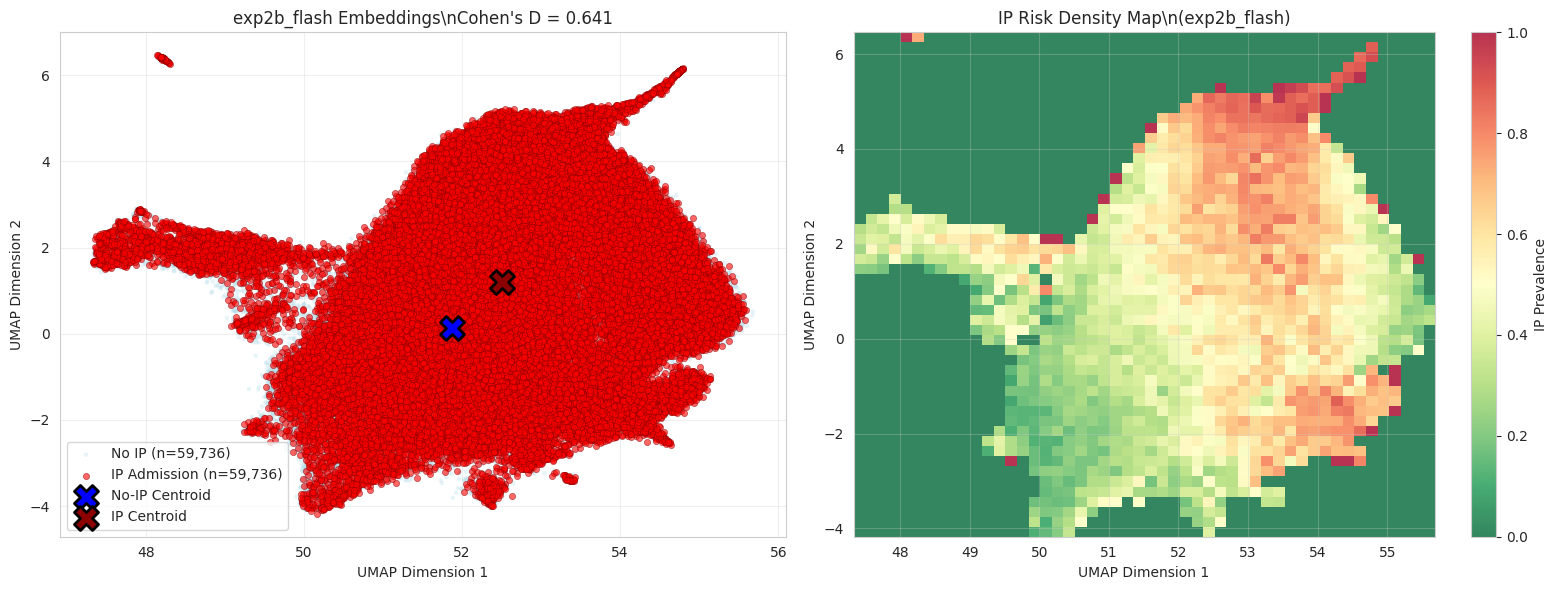

✅ Visualizations complete


In [20]:
print("🎨 Creating visualizations for ALTERNATIVE embeddings...\n")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Alternative embedding scatter
ax = axes[0]
ax.scatter(df_no_ip_viz_alt['umap_x'], df_no_ip_viz_alt['umap_y'], 
           c='lightblue', alpha=0.3, s=10, label=f'No IP (n={len(df_no_ip_viz_alt):,})', edgecolors='none')
ax.scatter(df_ip_viz_alt['umap_x'], df_ip_viz_alt['umap_y'], 
           c='red', alpha=0.6, s=20, label=f'IP Admission (n={len(df_ip_viz_alt):,})', edgecolors='darkred', linewidths=0.5)
ax.scatter(*centroid_no_ip_alt, marker='X', s=300, c='blue', edgecolors='black', linewidths=2, label='No-IP Centroid', zorder=10)
ax.scatter(*centroid_ip_alt, marker='X', s=300, c='darkred', edgecolors='black', linewidths=2, label='IP Centroid', zorder=10)
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.set_title(f'exp2b_flash Embeddings\\nCohen\'s D = {cohens_d_alt:.3f}')
ax.legend()
ax.grid(alpha=0.3)

# Plot 2: Heatmap
ax = axes[1]
h_alt, xedges_alt, yedges_alt = np.histogram2d(df_viz_alt['umap_x'], df_viz_alt['umap_y'], bins=50)
h_ip_alt, _, _ = np.histogram2d(df_ip_viz_alt['umap_x'], df_ip_viz_alt['umap_y'], bins=[xedges_alt, yedges_alt])

with np.errstate(divide='ignore', invalid='ignore'):
    ip_prevalence_alt = h_ip_alt / h_alt
    ip_prevalence_alt = np.nan_to_num(ip_prevalence_alt, nan=0)

im = ax.imshow(ip_prevalence_alt.T, origin='lower',
               extent=[xedges_alt[0], xedges_alt[-1], yedges_alt[0], yedges_alt[-1]],
               cmap='RdYlGn_r', aspect='auto', alpha=0.8)
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.set_title(f'IP Risk Density Map\\n(exp2b_flash)')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('IP Prevalence')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualizations complete")
